# Forecasting Austin Home Prices: From OLS to Machine Learning

**Research question:** Did the income–price relationship in Austin's housing market break after 2020 — and can next month's median sale price be predicted better than a naive baseline?

Three parts:
1. **Data pipeline** — a clean monthly panel (2015–2024) from FRED mortgage rates, Redfin housing data, and Census median income.
2. **Structural-break analysis** — income-only OLS by era, plus a Chow test for the pre/post-2020 break.
3. **ML forecasting** — lagged features, strict time-based validation, baselines vs. Ridge, Random Forest, and Gradient Boosting.

Data: FRED `MORTGAGE30US`, Redfin Data Center, US Census ACS 1-year estimates. All public sources, no PII.


## 1 · Data pipeline

Each source is read once, transformed, and merged into a single monthly panel saved as `austin_final_research_dataset.csv`


### Mortgage rates — FRED 30Y fixed

In [20]:
import pandas as pd
m = pd.read_csv('MORTGAGE30US.csv')
m.columns = m.columns.str.strip()
m['observation_date'] = pd.to_datetime(m['observation_date'])
m['Year_Month'] = m['observation_date'].dt.strftime('%Y-%m')
m = m.rename(columns={'MORTGAGE30US': 'Mortgage_Rate_30Y_Pct'})
m = m[['Year_Month', 'Mortgage_Rate_30Y_Pct']].dropna()

print("Mortgage rows:", len(m), "| Range:", m['Year_Month'].min(), "→", m['Year_Month'].max())
print(m.head(3).to_string(index=False))

Mortgage rows: 120 | Range: 2015-01 → 2024-12
Year_Month  Mortgage_Rate_30Y_Pct
   2015-01                    1.3
   2015-02                    1.3
   2015-03                    1.3


### Housing market — Redfin (Austin-Round Rock)

In [21]:

r = pd.read_csv('Redfin.csv')
a = r[r['REGION NAME'] == 'Austin, TX metro area'].copy()
a['PERIOD BEGIN'] = pd.to_datetime(a['PERIOD BEGIN'])
a['Year_Month'] = a['PERIOD BEGIN'].dt.strftime('%Y-%m')
a = a.sort_values('Year_Month').reset_index(drop=True)

print("Austin monthly rows:", len(a), "| Range:", a['Year_Month'].min(), "→", a['Year_Month'].max())

Austin monthly rows: 120 | Range: 2015-01 → 2024-12


### Merge to one monthly panel

In [22]:
merged = pd.merge(a, m, on='Year_Month', how='inner')

rename_schema = {
    'Year_Month': 'Year_Month',
    'REGION NAME': 'Region_Name',
    'MEDIAN SALE PRICE ($)': 'Median_Sale_Price_USD',
    'Mortgage_Rate_30Y_Pct': 'Mortgage_Rate_30Y_Pct',
    'HOMES SOLD': 'Homes_Sold',
    'MEDIAN DAYS ON MARKET (DAYS)': 'Median_Days_On_Market',
    'NEW LISTINGS': 'New_Listings',
    'ACTIVE LISTINGS': 'Active_Listings',
    'PENDING SALES': 'Pending_Sales',
}
cols = ['Year_Month', 'REGION NAME', 'MEDIAN SALE PRICE ($)', 'Mortgage_Rate_30Y_Pct',
        'HOMES SOLD', 'MEDIAN DAYS ON MARKET (DAYS)', 'NEW LISTINGS',
        'ACTIVE LISTINGS', 'PENDING SALES']
housing = merged[cols].rename(columns=rename_schema)
print("Merged shape:", housing.shape)

Merged shape: (120, 9)


### Median household income — Census ACS

In [23]:
import glob
import re
records = []
for fp in sorted(glob.glob('*Median Income.csv')):
    year = int(re.search(r'(\d{4})', fp).group(1))
    t = pd.read_csv(fp)
    t.columns = t.columns.str.strip()
    row = t[t['Label (Grouping)'].astype(str).str.strip() == 'Median income (dollars)']
    if not row.empty:
        records.append({'year': year,
                        'Median_Household_Income_USD': float(str(row.iloc[0, 1]).replace(',', ''))})

income = pd.DataFrame(records).sort_values('year').reset_index(drop=True)
print(income.to_string(index=False))

 year  Median_Household_Income_USD
 2015                      67195.0
 2016                      71000.0
 2017                      73800.0
 2018                      76925.0
 2019                      80954.0
 2020                      80852.0
 2021                      86530.0
 2022                      94604.0
 2023                      98508.0
 2024                      99897.0


In [24]:

housing['year'] = housing['Year_Month'].str[:4].astype(int)
final = pd.merge(housing, income, on='year', how='inner').drop(columns='year')
final.to_csv('austin_final_research_dataset.csv', index=False)
print("Final dataset:", final.shape, "— saved as austin_final_research_dataset.csv")

Final dataset: (120, 10) — saved as austin_final_research_dataset.csv


## 2 · Structural-break analysis

Income-only OLS, estimated separately pre/post-2020, then a Chow test for whether the break is statistically real.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from scipy.stats import f as fdist

sns.set_theme(style="whitegrid")

# Load ONCE. Everything downstream uses this dataframe.
df = pd.read_csv('austin_final_research_dataset.csv')
df['Year_Month'] = pd.to_datetime(df['Year_Month'])
df = df.sort_values('Year_Month').reset_index(drop=True)
df['year'] = df['Year_Month'].dt.year
df['Era'] = np.where(df['year'] <= 2019, 'Pre-pandemic', 'Post-pandemic')
df['Price_to_Income_Ratio'] = df['Median_Sale_Price_USD'] / df['Median_Household_Income_USD']
print("Loaded:", df.shape)

Loaded: (120, 13)


### Data audit

Date range, missing values, and duplicate months — before any modeling.

In [26]:

print("Date range:", df['Year_Month'].min().date(), "→", df['Year_Month'].max().date())
print("Missing values:\n", df.isna().sum().to_string())
print("\nDuplicate months:", df['Year_Month'].duplicated().sum())

Date range: 2015-01-01 → 2024-12-01
Missing values:
 Year_Month                     0
Region_Name                    0
Median_Sale_Price_USD          0
Mortgage_Rate_30Y_Pct          0
Homes_Sold                     0
Median_Days_On_Market          0
New_Listings                   0
Active_Listings                0
Pending_Sales                  0
Median_Household_Income_USD    0
year                           0
Era                            0
Price_to_Income_Ratio          0

Duplicate months: 0


### Income-only OLS, by era

**Result.** Pre-pandemic (2015–2019, n=60): R² = 0.765. Post-pandemic (2020–2024, n=60): R² = 0.386 — a **49.5% relative decline** in explanatory power. Income explained Austin prices well until 2020; then the relationship weakened sharply.


In [27]:
for era_name, sub in [('Pre-pandemic (2015–2019)', df[df['year'] <= 2019]),
                     ('Post-pandemic (2020–2024)', df[df['year'] >= 2020])]:
    X = sm.add_constant(sub['Median_Household_Income_USD'])
    res = sm.OLS(sub['Median_Sale_Price_USD'], X).fit()
    print(f"{era_name}: R² = {res.rsquared:.3f}  (n = {len(sub)})")

r2_pre = sm.OLS(df[df['year'] <= 2019]['Median_Sale_Price_USD'],
                sm.add_constant(df[df['year'] <= 2019]['Median_Household_Income_USD'])).fit().rsquared
r2_post = sm.OLS(df[df['year'] >= 2020]['Median_Sale_Price_USD'],
                sm.add_constant(df[df['year'] >= 2020]['Median_Household_Income_USD'])).fit().rsquared
print(f"\nRelative R² decline: {(r2_pre - r2_post) / r2_pre:.1%}")

Pre-pandemic (2015–2019): R² = 0.765  (n = 60)
Post-pandemic (2020–2024): R² = 0.386  (n = 60)

Relative R² decline: 49.5%


### Chow test: is the break statistically real?

Two R² values suggest a break; the Chow test checks it formally — whether one pooled regression fits as well as two era-specific ones.

**Result.** F = 17.3, p < 0.001 (split at 2020-01-01). The income–price relationship is statistically different across eras — the break is real, not a visual artifact.


In [28]:
def chow_test(y, X, split_at):
    """Chow test for a structural break at row split_at. X must include a constant."""
    n, k = X.shape
    rss_pooled = sm.OLS(y, X).fit().ssr
    rss1 = sm.OLS(y.iloc[:split_at], X.iloc[:split_at]).fit().ssr
    rss2 = sm.OLS(y.iloc[split_at:], X.iloc[split_at:]).fit().ssr
    F = ((rss_pooled - (rss1 + rss2)) / k) / ((rss1 + rss2) / (n - 2 * k))
    p = 1 - fdist.cdf(F, k, n - 2 * k)
    return F, p

y_all = df['Median_Sale_Price_USD']
X_all = sm.add_constant(df['Median_Household_Income_USD'])
split_at = int(np.argmax((df['year'] >= 2020).to_numpy()))  # first post-2019 row
F, p = chow_test(y_all, X_all, split_at)
print(f"Chow F = {F:.1f}, p = {p:.4f}")
print("Split at:", df.loc[split_at, 'Year_Month'].date())
print("→ p < 0.05 means the pre/post-2020 relationship is statistically different.")

Chow F = 17.3, p = 0.0000
Split at: 2020-01-01
→ p < 0.05 means the pre/post-2020 relationship is statistically different.


### The decoupling, visualized

Fitted income–price relationship by era — the same regressions as above, plotted.

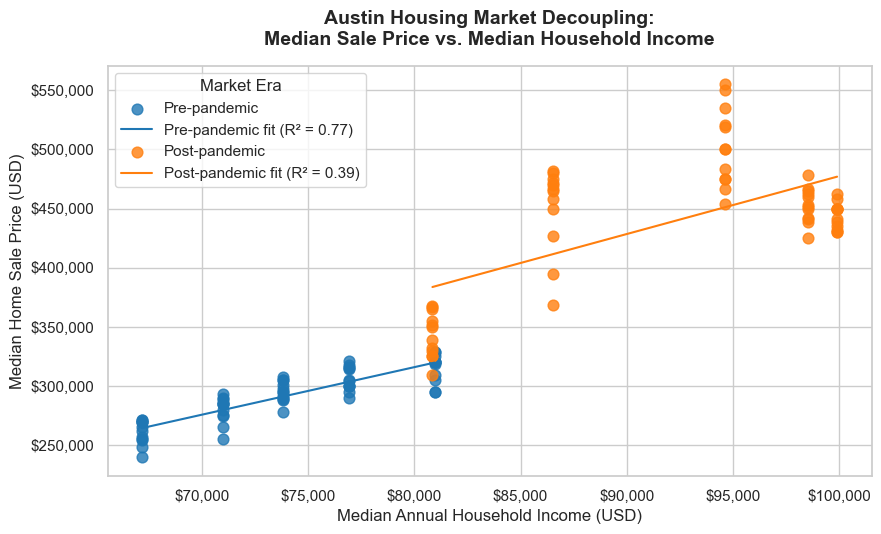

In [29]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for era, color in [('Pre-pandemic', '#1f77b4'), ('Post-pandemic', '#ff7f0e')]:
    sub = df[df['Era'] == era]
    ax.scatter(sub['Median_Household_Income_USD'], sub['Median_Sale_Price_USD'],
               color=color, alpha=0.8, s=60, label=era)
    X = sm.add_constant(sub['Median_Household_Income_USD'])
    res = sm.OLS(sub['Median_Sale_Price_USD'], X).fit()
    xs = np.linspace(sub['Median_Household_Income_USD'].min(),
                     sub['Median_Household_Income_USD'].max(), 50)
    ax.plot(xs, res.params['const'] + res.params['Median_Household_Income_USD'] * xs,
            color=color, label=f"{era} fit (R² = {res.rsquared:.2f})")
ax.set_title('Austin Housing Market Decoupling:\nMedian Sale Price vs. Median Household Income',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Median Annual Household Income (USD)', fontsize=12)
ax.set_ylabel('Median Home Sale Price (USD)', fontsize=12)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f"${int(x):,}"))
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f"${int(x):,}"))
ax.legend(title='Market Era', loc='upper left')
plt.tight_layout()
plt.savefig('austin_decoupling_clean.png', dpi=150)

### Prices vs. mortgage rates

*Rates fell while prices rose* — that is what this chart shows. It does not show that rates *caused* the rise. Association, not causation, throughout.


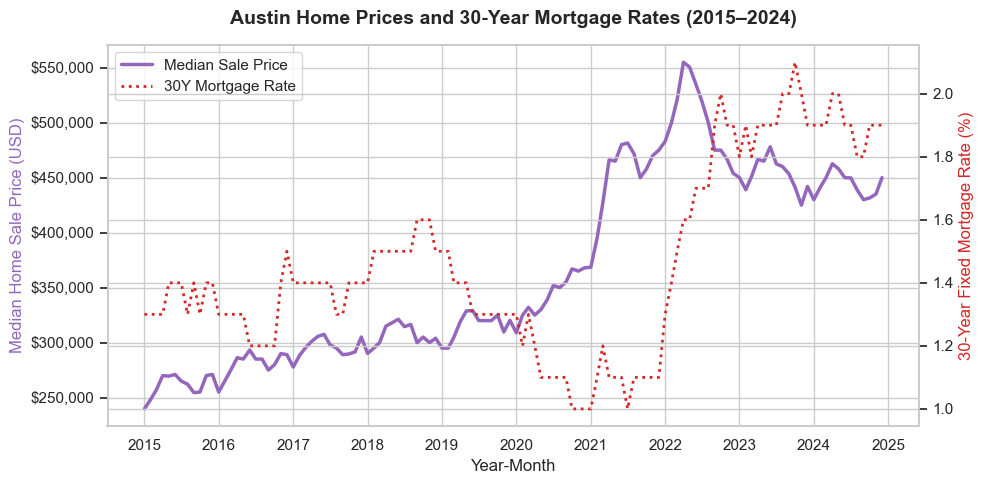

In [30]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(df['Year_Month'], df['Median_Sale_Price_USD'], color='#9467bd',
         linewidth=2.5, label='Median Sale Price')
ax2.plot(df['Year_Month'], df['Mortgage_Rate_30Y_Pct'], color='#d62728',
         linestyle=':', linewidth=2, label='30Y Mortgage Rate')
ax1.set_title('Austin Home Prices and 30-Year Mortgage Rates (2015–2024)',
             fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Year-Month', fontsize=12)
ax1.set_ylabel('Median Home Sale Price (USD)', color='#9467bd', fontsize=12)
ax2.set_ylabel('30-Year Fixed Mortgage Rate (%)', color='#d62728', fontsize=12)
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f"${int(x):,}"))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('austin_price_vs_rates_clean.png', dpi=150)

## 3 · ML forecasting

New question: Instead of *explaining* prices with income, can we *predict* next month's median price — and beat a naive baseline? With ~108 usable monthly rows this is small-data ML: the methodology (leakage control, baselines, time-based validation) is the point, and it transfers to any dataset.


### Leakage control

Two rules, applied throughout: (1) split by **time**, never shuffle — train on the past, test on the future; (2) every feature is **lagged ≥ 1 month** — at prediction time, only the past is known.


### Feature engineering

24 features, all lagged: price lags (1/3/6/12 mo), rolling price averages, mortgage-rate level and change, inventory / days-on-market / sales, lagged affordability ratio, annual income, and month-of-year dummies for seasonality.


In [31]:
def make_features(data):
    """Build lagged features. Every feature uses data available BEFORE month t
    to predict month t's price — no leakage by construction."""
    d = data.sort_values('Year_Month').reset_index(drop=True).copy()
    p = 'Median_Sale_Price_USD'

    for lag in (1, 3, 6, 12):
        d[f'price_lag{lag}'] = d[p].shift(lag)
    d['price_roll3'] = d[p].shift(1).rolling(3).mean()
    d['price_roll12'] = d[p].shift(1).rolling(12).mean()
 
    d['mortgage_lag1'] = d['Mortgage_Rate_30Y_Pct'].shift(1)
    d['mortgage_chg3'] = d['Mortgage_Rate_30Y_Pct'].shift(1) - d['Mortgage_Rate_30Y_Pct'].shift(4)

    d['inventory_lag1'] = d['Active_Listings'].shift(1)
    d['dom_lag1'] = d['Median_Days_On_Market'].shift(1)
    d['sales_lag1'] = d['Homes_Sold'].shift(1)

    d['afford_lag1'] = d['Price_to_Income_Ratio'].shift(1)
    d['income'] = d['Median_Household_Income_USD']

    d = d.dropna().reset_index(drop=True)  

    dummies = pd.get_dummies(d['Year_Month'].dt.month, prefix='m',
                             drop_first=True).astype(float)
    return pd.concat([d, dummies], axis=1)

d = make_features(df)
NUM = ['price_lag1', 'price_lag3', 'price_lag6', 'price_lag12', 'price_roll3',
       'price_roll12', 'mortgage_lag1', 'mortgage_chg3', 'inventory_lag1',
       'dom_lag1', 'sales_lag1', 'afford_lag1', 'income']
FEATURES = NUM + [c for c in d.columns if c.startswith('m_')]
print(f"Rows after lags: {len(d)} | Features: {len(FEATURES)}")

Rows after lags: 108 | Features: 24


### Time-based train/test split

Train on 2015–2021 (72 months), test on 2022–2024 (36 months): had this been built in January 2022, how would it have done?


In [32]:
train = d[d['Year_Month'] < '2022-01-01']
test = d[d['Year_Month'] >= '2022-01-01']
X_train, y_train = train[FEATURES], train['Median_Sale_Price_USD']
X_test, y_test = test[FEATURES], test['Median_Sale_Price_USD']
print(f"Train: {len(train)} months (2015–2021) | Test: {len(test)} months (2022–2024)")

Train: 72 months (2015–2021) | Test: 36 months (2022–2024)


### Baselines before models

Two baselines every model must beat: **naive persistence** (this month = last month's price — embarrassingly hard to beat in housing data) and **income-only OLS** (the Part 2 spec, refit on the training window). Models: Ridge (regularized linear), Random Forest, and gradient boosting (`HistGradientBoostingRegressor` — same algorithm family as XGBoost/LightGBM).


In [33]:
def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

rows = []
rows.append(("Naive (last month's price)",
             rmse(y_test, test['price_lag1']),
             mean_absolute_error(y_test, test['price_lag1'])))
ols = sm.OLS(y_train, sm.add_constant(X_train[['income']])).fit()
ols_pred = ols.predict(sm.add_constant(X_test[['income']]))
rows.append(("OLS (income only)",
             rmse(y_test, ols_pred), mean_absolute_error(y_test, ols_pred)))

fitted = {
    "Ridge": RidgeCV(alphas=np.logspace(-2, 3, 12)).fit(X_train, y_train),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42,
                                           n_jobs=-1).fit(X_train, y_train),
    "Gradient Boosting": HistGradientBoostingRegressor(random_state=42).fit(X_train, y_train),
}
for name, model in fitted.items():
    pred = model.predict(X_test)
    rows.append((name, rmse(y_test, pred), mean_absolute_error(y_test, pred)))

results = pd.DataFrame(rows, columns=['model', 'RMSE', 'MAE']).sort_values('RMSE')
print(results.to_string(index=False, formatters={'RMSE': '{:,.0f}'.format,
                                                 'MAE': '{:,.0f}'.format}))

                     model   RMSE    MAE
                     Ridge 10,647  8,744
Naive (last month's price) 13,334 11,266
             Random Forest 32,897 23,116
         Gradient Boosting 50,784 40,741
         OLS (income only) 75,989 68,447


### Time-series cross-validation — and model selection

One split is one roll of the dice. `TimeSeriesSplit` rolls the origin forward (train 2015–17 → test 2018, etc.); the mean is a sturdier generalization estimate.

This is also where the winner gets picked: the model with the lowest mean CV error becomes `best_name`. Selection happens here, on validation folds — the 2022–2024 holdout is only ever used for the final report, never for choosing.

In [ ]:
# Model selection by time-series CV. The holdout stays untouched until final evaluation.
tscv = TimeSeriesSplit(n_splits=3)
cv_models = {
    "Ridge": RidgeCV(alphas=np.logspace(-2, 3, 12)),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
}

cv_scores = {}
for name, model in cv_models.items():
    fold_rmses = []
    for tr_idx, te_idx in tscv.split(X_train):
        model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        fold_rmses.append(rmse(y_train.iloc[te_idx], model.predict(X_train.iloc[te_idx])))
    cv_scores[name] = float(np.mean(fold_rmses))
    folds_str = ", ".join(f"${v:,.0f}" for v in fold_rmses)
    print(f"{name}: folds = [{folds_str}] -> mean ${cv_scores[name]:,.0f}")

best_name = min(cv_scores, key=cv_scores.get)
print("\nBest by CV:", best_name)

In [ ]:
best_pred = fitted[best_name].predict(X_test)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test['Year_Month'], y_test, color='black', lw=2, label='Actual')
ax.plot(test['Year_Month'], best_pred, color='#1f77b4', lw=2,
        label=f'{best_name} (test RMSE ${rmse(y_test, best_pred):,.0f})')
ax.plot(test['Year_Month'], test['price_lag1'], color='gray', ls='--', lw=1.5,
        label='Naive baseline')
ax.set_title('Holdout test (2022–2024): actual vs. predicted median price',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Median Sale Price (USD)')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f"${int(x):,}"))
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('austin_ml_holdout.png', dpi=150)

### Results — 2022–2024 holdout

| Model | RMSE | MAE |
|---|---|---|
| **Ridge** | **$10,647** | **$8,744** |
| Naive (last month's price) | $13,334 | $11,266 |
| Random Forest | $32,897 | $23,116 |
| Gradient Boosting | $50,784 | $40,741 |
| OLS (income only) | $75,989 | $68,447 |

**Ridge wins, cutting holdout RMSE ~20% vs. naive persistence.** The tree ensembles lost to the naive baseline — on 72 training rows with 24 features they overfit, and trees cannot extrapolate beyond the training range into a new regime (the Part 2 break). Note the warning for modelers: the income-only OLS that fit well in-sample (R² = 0.765 pre-2020) is the *worst* predictor out of sample. Explaining the past ≠ predicting the future.


### Permutation feature importance (Ridge)

Top predictors: last month's price, active inventory, 3-month price trend, days on market, and spring/summer month dummies (seasonality). Mortgage-rate and income features rank outside the top 12 — once the model knows recent prices and inventory, rates add little *marginal* monthly signal (their slow-moving effect is largely absorbed by price momentum). Predictive importance, not causal proof.


price_lag1        47109
inventory_lag1    28388
price_roll3       27642
dom_lag1          18562
m_4               12482
price_lag12       11238
price_roll12      10723
price_lag3        10330
m_6                9818
m_12               8678
m_3                8085
m_8                7474


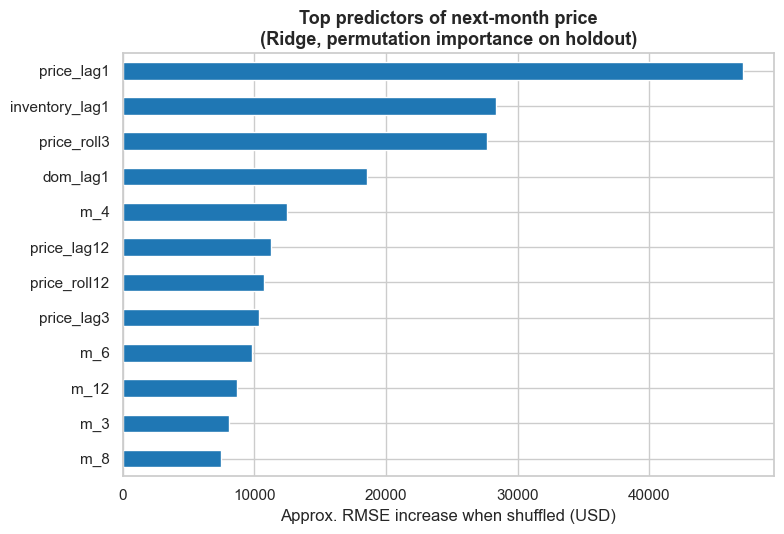

In [36]:
best = fitted[best_name]
r = permutation_importance(best, X_test, y_test, n_repeats=10, random_state=42,
                           scoring="neg_mean_squared_error")
imp = pd.Series(np.sqrt(r.importances_mean), index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5.5))
imp.head(12).sort_values().plot.barh(ax=ax, color='#1f77b4')
ax.set_title(f'Top predictors of next-month price\n({best_name}, permutation importance on holdout)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Approx. RMSE increase when shuffled (USD)')
plt.tight_layout()
plt.savefig('austin_feature_importance.png', dpi=150)
print(imp.head(12).round(0).astype(int).to_string())

## Limitations

- **~108 usable months is small for ML** — treat the Ridge-vs-trees ranking as suggestive; more metros or weekly frequency would strengthen it.
- **Income is annual**, repeated across months; its importance is understated at monthly grain.
- **One metro** — the 2020 break may be Austin-specific (migration, tech). The upgrade is panel data: many metros, one model.
- **Prediction, not causation** — nothing here proves mechanism.


## Takeaways

1. Austin's income–price relationship broke after 2020 (Chow F = 17.3, p < 0.001; R² 0.765 → 0.386, a 49.5% decline).
2. A regularized linear model with lagged features beat naive persistence by ~20% RMSE on a true 2022–2024 holdout.
3. On small data, simplicity won: tree ensembles overfit and lost to "last month's price."
4. In-sample fit misleads — the OLS spec with R² = 0.765 was the worst forecaster.
